# Dressed Spectrum: Flux-Tunable Transmon + Linear Oscillator

Computes and plots the dressed eigenenergies and transition frequencies as a function of external flux $\Phi_{ext}/\Phi_0$.

**System:**
- Flux-tunable transmon with asymmetric SQUID
- Linear oscillator at fixed frequency
- Capacitive (charge-charge) coupling

$$H = \omega_q(\phi)\, b^\dagger b + \frac{\alpha}{2} b^\dagger b^\dagger b b + \omega_r\, a^\dagger a + g(a + a^\dagger)(b + b^\dagger)$$

$$\omega_q(\phi) = \sqrt{8 E_C E_J(\phi)} - E_C \qquad E_J(\phi) = E_{J,\max}\left|\cos(\pi\phi)\right|\sqrt{1 + d^2 \tan^2(\pi\phi)}$$

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

print(f'QuTiP version: {qt.__version__}')

QuTiP version: 5.2.2


## System Parameters
All frequencies in GHz. Edit these to match your device.

In [27]:
params = dict(
    # transmon
    Ec        = 0.0600,     # GHz — charging energy
    Ej_max    = 33.0,      # GHz — max Josephson energy (sum of two junctions)
    d         = 0.00,      # junction asymmetry: (Ej2-Ej1)/(Ej2+Ej1), 0 = symmetric

    # oscillator
    w_r       = 3.8,       # GHz — bare resonator frequency

    # coupling
    g         = 0.5,       # GHz — coupling strength

    # Hilbert space truncation
    N_q       = 5,         # transmon levels
    N_r       = 6,         # oscillator levels

    # flux sweep
    phi_min   = 0.0,       # Phi/Phi_0
    phi_max   = 1.0,
    n_phi     = 200,
)

# quick sanity check: bare qubit freq at zero flux
w_q0 = np.sqrt(8 * params['Ec'] * params['Ej_max']) - params['Ec']
print(f"Bare qubit freq at Phi=0:  {w_q0:.3f} GHz")
print(f"Anharmonicity:             {-params['Ec']*1e3:.1f} MHz")
print(f"Bare resonator freq:       {params['w_r']:.3f} GHz")
print(f"Bare detuning at Phi=0:    {(w_q0 - params['w_r'])*1e3:.1f} MHz")
print(f"Dispersive shift (approx): {params['g']**2 / (w_q0 - params['w_r'])*1e3:.1f} MHz")

Bare qubit freq at Phi=0:  3.920 GHz
Anharmonicity:             -60.0 MHz
Bare resonator freq:       3.800 GHz
Bare detuning at Phi=0:    119.9 MHz
Dispersive shift (approx): 2084.2 MHz


## Transmon Physics

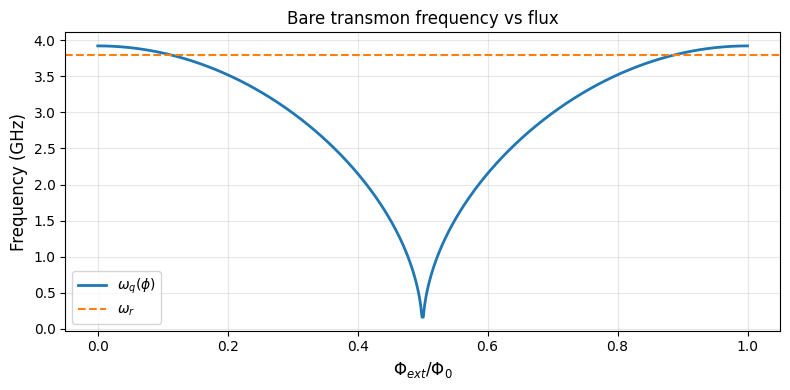

In [28]:
def ej_of_phi(phi, Ej_max, d):
    """Effective Josephson energy for asymmetric SQUID."""
    return Ej_max * np.abs(np.cos(np.pi * phi)) * \
           np.sqrt(1 + d**2 * np.tan(np.pi * phi)**2)


def w_transmon(phi, Ec, Ej_max, d):
    """Transmon ge transition frequency [GHz]. Leading order: sqrt(8*Ec*Ej) - Ec."""
    Ej = ej_of_phi(phi, Ej_max, d)
    return np.sqrt(8 * Ec * Ej) - Ec


def anharmonicity(Ec):
    """Transmon anharmonicity alpha ~ -Ec."""
    return -Ec


# plot bare transmon frequency vs flux
phi_plot = np.linspace(0, 1, 500)
# avoid singularity at phi=0.5 for d != 0
phi_safe = np.where(np.abs(phi_plot % 1.0 - 0.5) < 1e-4, phi_plot + 1e-4, phi_plot)
w_q_plot = np.array([w_transmon(p, params['Ec'], params['Ej_max'], params['d'])
                     for p in phi_safe])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(phi_plot, w_q_plot, 'C0', lw=2, label='$\\omega_q(\\phi)$')
ax.axhline(params['w_r'], color='C1', ls='--', lw=1.5, label='$\\omega_r$')
ax.set_xlabel('$\\Phi_{ext} / \\Phi_0$', fontsize=12)
ax.set_ylabel('Frequency (GHz)', fontsize=12)
ax.set_title('Bare transmon frequency vs flux', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Build Hamiltonian

In [29]:
def build_hamiltonian(phi, p):
    """
    Full coupled Hamiltonian at a given flux phi.

    H = w_q * b†b + (alpha/2) * b†b†bb
      + w_r * a†a
      + g  * (a + a†)(b + b†)

    Tensor structure: [resonator] x [transmon]
    """
    N_q = p['N_q']
    N_r = p['N_r']

    w_q   = w_transmon(phi, p['Ec'], p['Ej_max'], p['d'])
    alpha = anharmonicity(p['Ec'])
    w_r   = p['w_r']
    g     = p['g']

    # operators
    a  = qt.tensor(qt.destroy(N_r), qt.qeye(N_q))    # resonator
    b  = qt.tensor(qt.qeye(N_r),   qt.destroy(N_q))  # transmon

    H_r    = w_r  * a.dag() * a
    H_q    = w_q  * b.dag() * b + (alpha / 2) * b.dag() * b.dag() * b * b
    H_coup = g    * (a + a.dag()) * (b + b.dag())

    return H_r + H_q + H_coup

## Compute Dressed Spectrum

In [30]:
def compute_dressed_spectrum(p, n_levels=8):
    """
    Diagonalise H at each flux point.

    Returns
    -------
    phi_arr : (n_phi,)          flux points
    evals   : (n_phi, n_levels) eigenenergies [GHz], ground state subtracted
    """
    phi_arr = np.linspace(p['phi_min'], p['phi_max'], p['n_phi'])
    evals   = np.zeros((p['n_phi'], n_levels))

    for i, phi in enumerate(phi_arr):
        phi_safe = phi if abs(phi % 1.0 - 0.5) > 1e-4 else phi + 1e-4
        H = build_hamiltonian(phi_safe, p)
        energies  = H.eigenenergies()
        evals[i]  = energies[:n_levels]

    # subtract ground state
    evals -= evals[:, [0]]
    return phi_arr, evals


n_levels = 8
print(f'Diagonalising {params["n_phi"]} flux points '
      f'(Hilbert space dim = {params["N_r"] * params["N_q"]})...')
phi_arr, evals = compute_dressed_spectrum(params, n_levels=n_levels)
print('Done.')

Diagonalising 200 flux points (Hilbert space dim = 30)...
Done.


## Plot 1: Dressed Eigenenergies
All dressed levels $E_n - E_0$ vs flux, with bare frequencies overlaid as dashed lines.

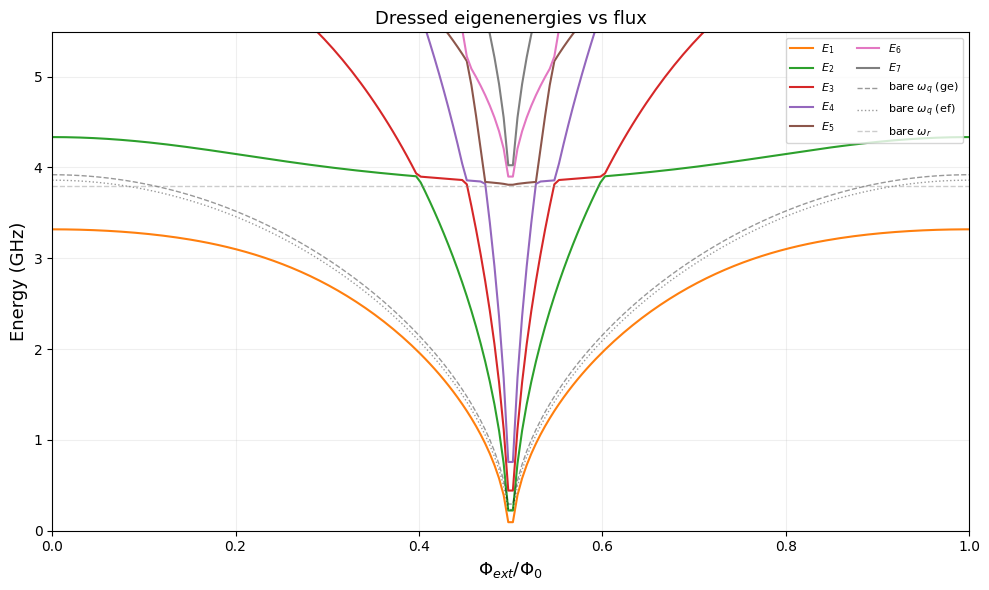

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab10(range(n_levels))
for n in range(1, n_levels):
    ax.plot(phi_arr, evals[:, n], color=colors[n], lw=1.5, label=f'$E_{n}$')

# bare frequencies for reference
phi_safe_arr = np.where(np.abs(phi_arr % 1.0 - 0.5) < 1e-4, phi_arr + 1e-4, phi_arr)
w_q_bare  = np.array([w_transmon(p, params['Ec'], params['Ej_max'], params['d'])
                      for p in phi_safe_arr])
w_ef_bare = w_q_bare + anharmonicity(params['Ec'])

ax.plot(phi_arr, w_q_bare,  'k--', lw=1, alpha=0.4, label='bare $\\omega_q$ (ge)')
ax.plot(phi_arr, w_ef_bare, 'k:',  lw=1, alpha=0.4, label='bare $\\omega_q$ (ef)')
ax.axhline(params['w_r'], color='gray', lw=1, ls='--', alpha=0.4,
           label='bare $\\omega_r$')

ax.set_xlabel('$\\Phi_{ext} / \\Phi_0$', fontsize=13)
ax.set_ylabel('Energy (GHz)', fontsize=13)
ax.set_title('Dressed eigenenergies vs flux', fontsize=13)
ax.set_xlim(phi_arr[0], phi_arr[-1])
ax.set_ylim(0, max(params['w_r'], w_q_bare.max()) * 1.4)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Plot 2: Dressed Transition Frequencies
$E_m - E_n$ vs flux. These are the frequencies you measure in spectroscopy.

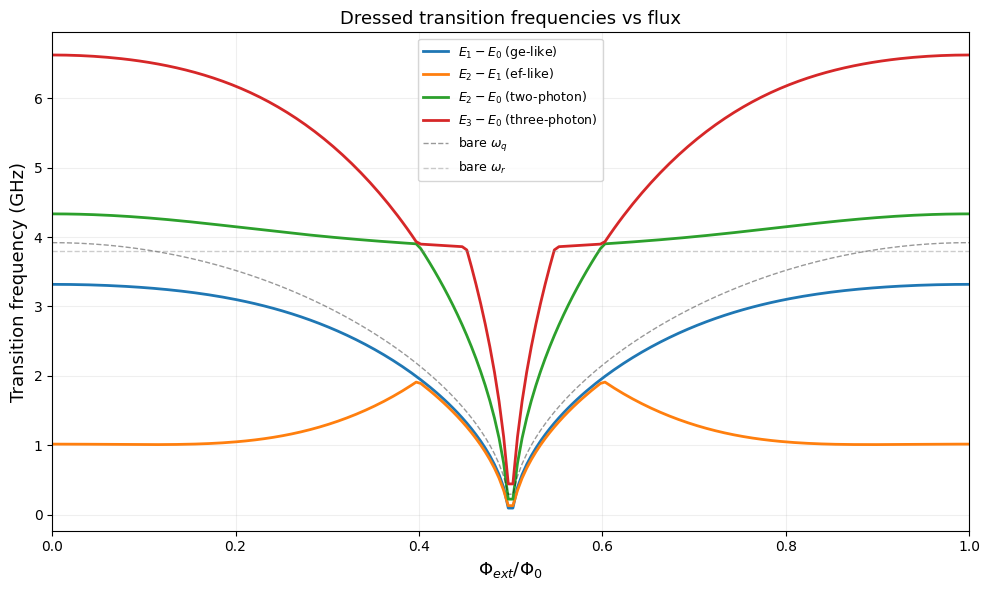

In [32]:
transitions = [
    (1, 0),   # qubit-like ge
    (2, 1),   # qubit-like ef
    (2, 0),   # two-photon
    (3, 0),   # three-photon
]
labels = [
    '$E_1 - E_0$ (ge-like)',
    '$E_2 - E_1$ (ef-like)',
    '$E_2 - E_0$ (two-photon)',
    '$E_3 - E_0$ (three-photon)',
]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(range(len(transitions)))

for (m, n), label, color in zip(transitions, labels, colors):
    ax.plot(phi_arr, evals[:, m] - evals[:, n], color=color, lw=2, label=label)

ax.plot(phi_arr, w_q_bare,  'k--', lw=1, alpha=0.4, label='bare $\\omega_q$')
ax.axhline(params['w_r'], color='gray', lw=1, ls='--', alpha=0.4,
           label='bare $\\omega_r$')

ax.set_xlabel('$\\Phi_{ext} / \\Phi_0$', fontsize=13)
ax.set_ylabel('Transition frequency (GHz)', fontsize=13)
ax.set_title('Dressed transition frequencies vs flux', fontsize=13)
ax.set_xlim(phi_arr[0], phi_arr[-1])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Plot 3: Dispersive Shift vs Flux
Chi approximated from the dressed spectrum:
$$\chi \approx \frac{1}{2}\left[(E_2 - E_1) - (E_1 - E_0)\right]$$
This tracks how the resonator frequency shifts per qubit excitation.

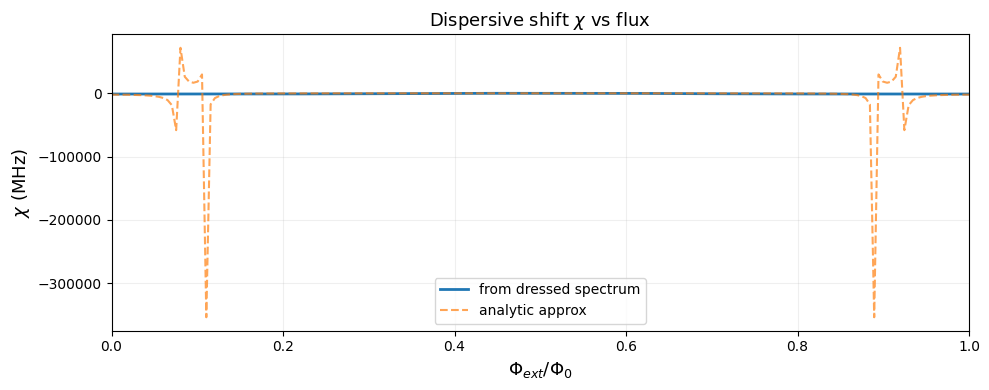

chi at Phi=0: -1151.48 MHz


In [33]:
# chi from dressed spectrum: half the difference of ge and ef transition energies
chi = 0.5 * ((evals[:, 2] - evals[:, 1]) - (evals[:, 1] - evals[:, 0]))

# analytic approximation: chi ~ g^2 * alpha / (Delta * (Delta + alpha))
Delta   = w_q_bare - params['w_r']
alpha   = anharmonicity(params['Ec'])
chi_approx = params['g']**2 * alpha / (Delta * (Delta + alpha))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(phi_arr, chi * 1e3,        'C0', lw=2, label='from dressed spectrum')
ax.plot(phi_arr, chi_approx * 1e3, 'C1--', lw=1.5, alpha=0.7, label='analytic approx')
ax.set_xlabel('$\\Phi_{ext} / \\Phi_0$', fontsize=13)
ax.set_ylabel('$\\chi$ (MHz)', fontsize=13)
ax.set_title('Dispersive shift $\\chi$ vs flux', fontsize=13)
ax.set_xlim(phi_arr[0], phi_arr[-1])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

chi0 = chi[0] * 1e3
print(f'chi at Phi=0: {chi0:.2f} MHz')

## Avoided Crossing Zoom
Zoom in around the avoided crossing between qubit and resonator.

Resonance near phi = 0.111, detuning = 0.7 MHz


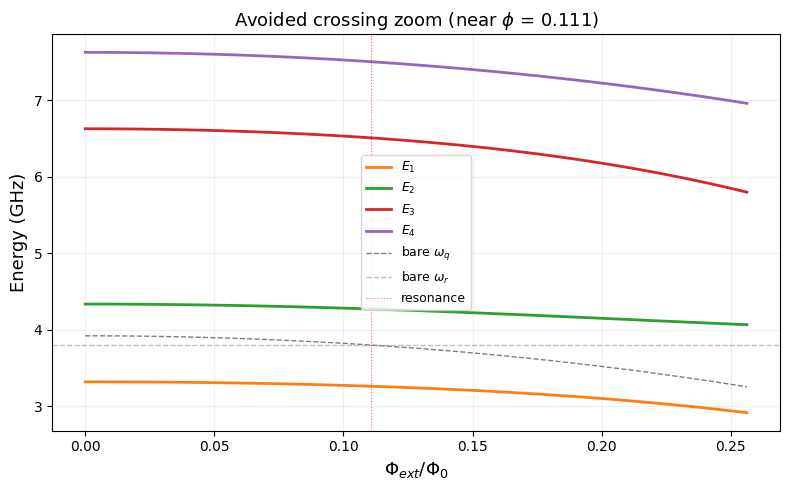

In [34]:
# find flux closest to resonance (where |w_q - w_r| is minimised)
detuning    = np.abs(w_q_bare - params['w_r'])
phi_res_idx = np.argmin(detuning)
phi_res     = phi_arr[phi_res_idx]
print(f'Resonance near phi = {phi_res:.3f}, detuning = {detuning[phi_res_idx]*1e3:.1f} MHz')

# zoom window
zoom_width = 0.15
mask = np.abs(phi_arr - phi_res) < zoom_width

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(range(n_levels))
for n in range(1, min(5, n_levels)):
    ax.plot(phi_arr[mask], evals[mask, n], color=colors[n], lw=2, label=f'$E_{n}$')

ax.plot(phi_arr[mask], w_q_bare[mask],  'k--', lw=1, alpha=0.5, label='bare $\\omega_q$')
ax.axhline(params['w_r'], color='gray', lw=1, ls='--', alpha=0.5, label='bare $\\omega_r$')
ax.axvline(phi_res, color='red', lw=0.8, ls=':', alpha=0.6, label='resonance')

ax.set_xlabel('$\\Phi_{ext} / \\Phi_0$', fontsize=13)
ax.set_ylabel('Energy (GHz)', fontsize=13)
ax.set_title(f'Avoided crossing zoom (near $\\phi$ = {phi_res:.3f})', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()